In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.graph_objects as go
import re
import tensorflow as tf
# from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, add
from tensorflow.keras.layers import Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import corpus_bleu
from PIL import Image
from tqdm import tqdm_notebook
from collections import Counter

In [2]:
# Path to the images
images_directory = '/kaggle/input/flickr8k/Images/'
# Path to the captions
captions_path = '/kaggle/input/flickr8k/captions.txt'

In [3]:
def load_captions(file_path):
    with open(file_path, 'r') as f:
        captions = f.readlines()
        # Lowercasing  the captions
        captions = [caption.lower() for caption in captions[1:]]
    return captions

def tokenize_captions(captions):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(captions)
    return tokenizer

# Loading the captions from the dataset
captions = load_captions(captions_path)
captions[:15:3]

['1000268201_693b08cb0e.jpg,a child in a pink dress is climbing up a set of stairs in an entry way .\n',
 '1000268201_693b08cb0e.jpg,a little girl climbing the stairs to her playhouse .\n',
 '1001773457_577c3a7d70.jpg,a black dog and a tri-colored dog playing with each other on the road .\n',
 '1001773457_577c3a7d70.jpg,two dogs on pavement moving toward each other .\n',
 '1002674143_1b742ab4b8.jpg,a small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it .\n']

In [4]:
def clean_text(text):
    # Removing punctuation marks
    text = re.sub(r'[^\w\s]', '', text)
    
    # Removing numbers
    text = re.sub(r'\d+', '', text)
    
    # Removing extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Cleaning the captions
cleaned_captions = [clean_text(caption.split(',')[1]) for caption in captions]
cleaned_captions[:15:2]

['a child in a pink dress is climbing up a set of stairs in an entry way',
 'a little girl climbing into a wooden playhouse',
 'a little girl in a pink dress going into a wooden cabin',
 'a black dog and a tricolored dog playing with each other on the road',
 'two dogs of different breeds looking at each other on the road',
 'a little girl covered in paint sits in front of a painted rainbow with her hands in a bowl',
 'a small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it',
 'young girl with pigtails painting outside in the grass']

In [5]:
# Image ID + \t + Caption
captions_IDs = []
for i in range(len(cleaned_captions)):
    #  Adding 'start' word and 'end' word to the captions
    item = captions[i].split(',')[0]+'\t'+'start '+cleaned_captions[i]+' end\n'
    captions_IDs.append(item)
    
captions_IDs[:20:3], len(captions_IDs)

(['1000268201_693b08cb0e.jpg\tstart a child in a pink dress is climbing up a set of stairs in an entry way end\n',
  '1000268201_693b08cb0e.jpg\tstart a little girl climbing the stairs to her playhouse end\n',
  '1001773457_577c3a7d70.jpg\tstart a black dog and a tricolored dog playing with each other on the road end\n',
  '1001773457_577c3a7d70.jpg\tstart two dogs on pavement moving toward each other end\n',
  '1002674143_1b742ab4b8.jpg\tstart a small girl in the grass plays with fingerpaints in front of a white canvas with a rainbow on it end\n',
  '1003163366_44323f5815.jpg\tstart a man lays on a bench while his dog sits by him end\n',
  '1003163366_44323f5815.jpg\tstart a shirtless man lies on a park bench with his dog end\n'],
 40455)

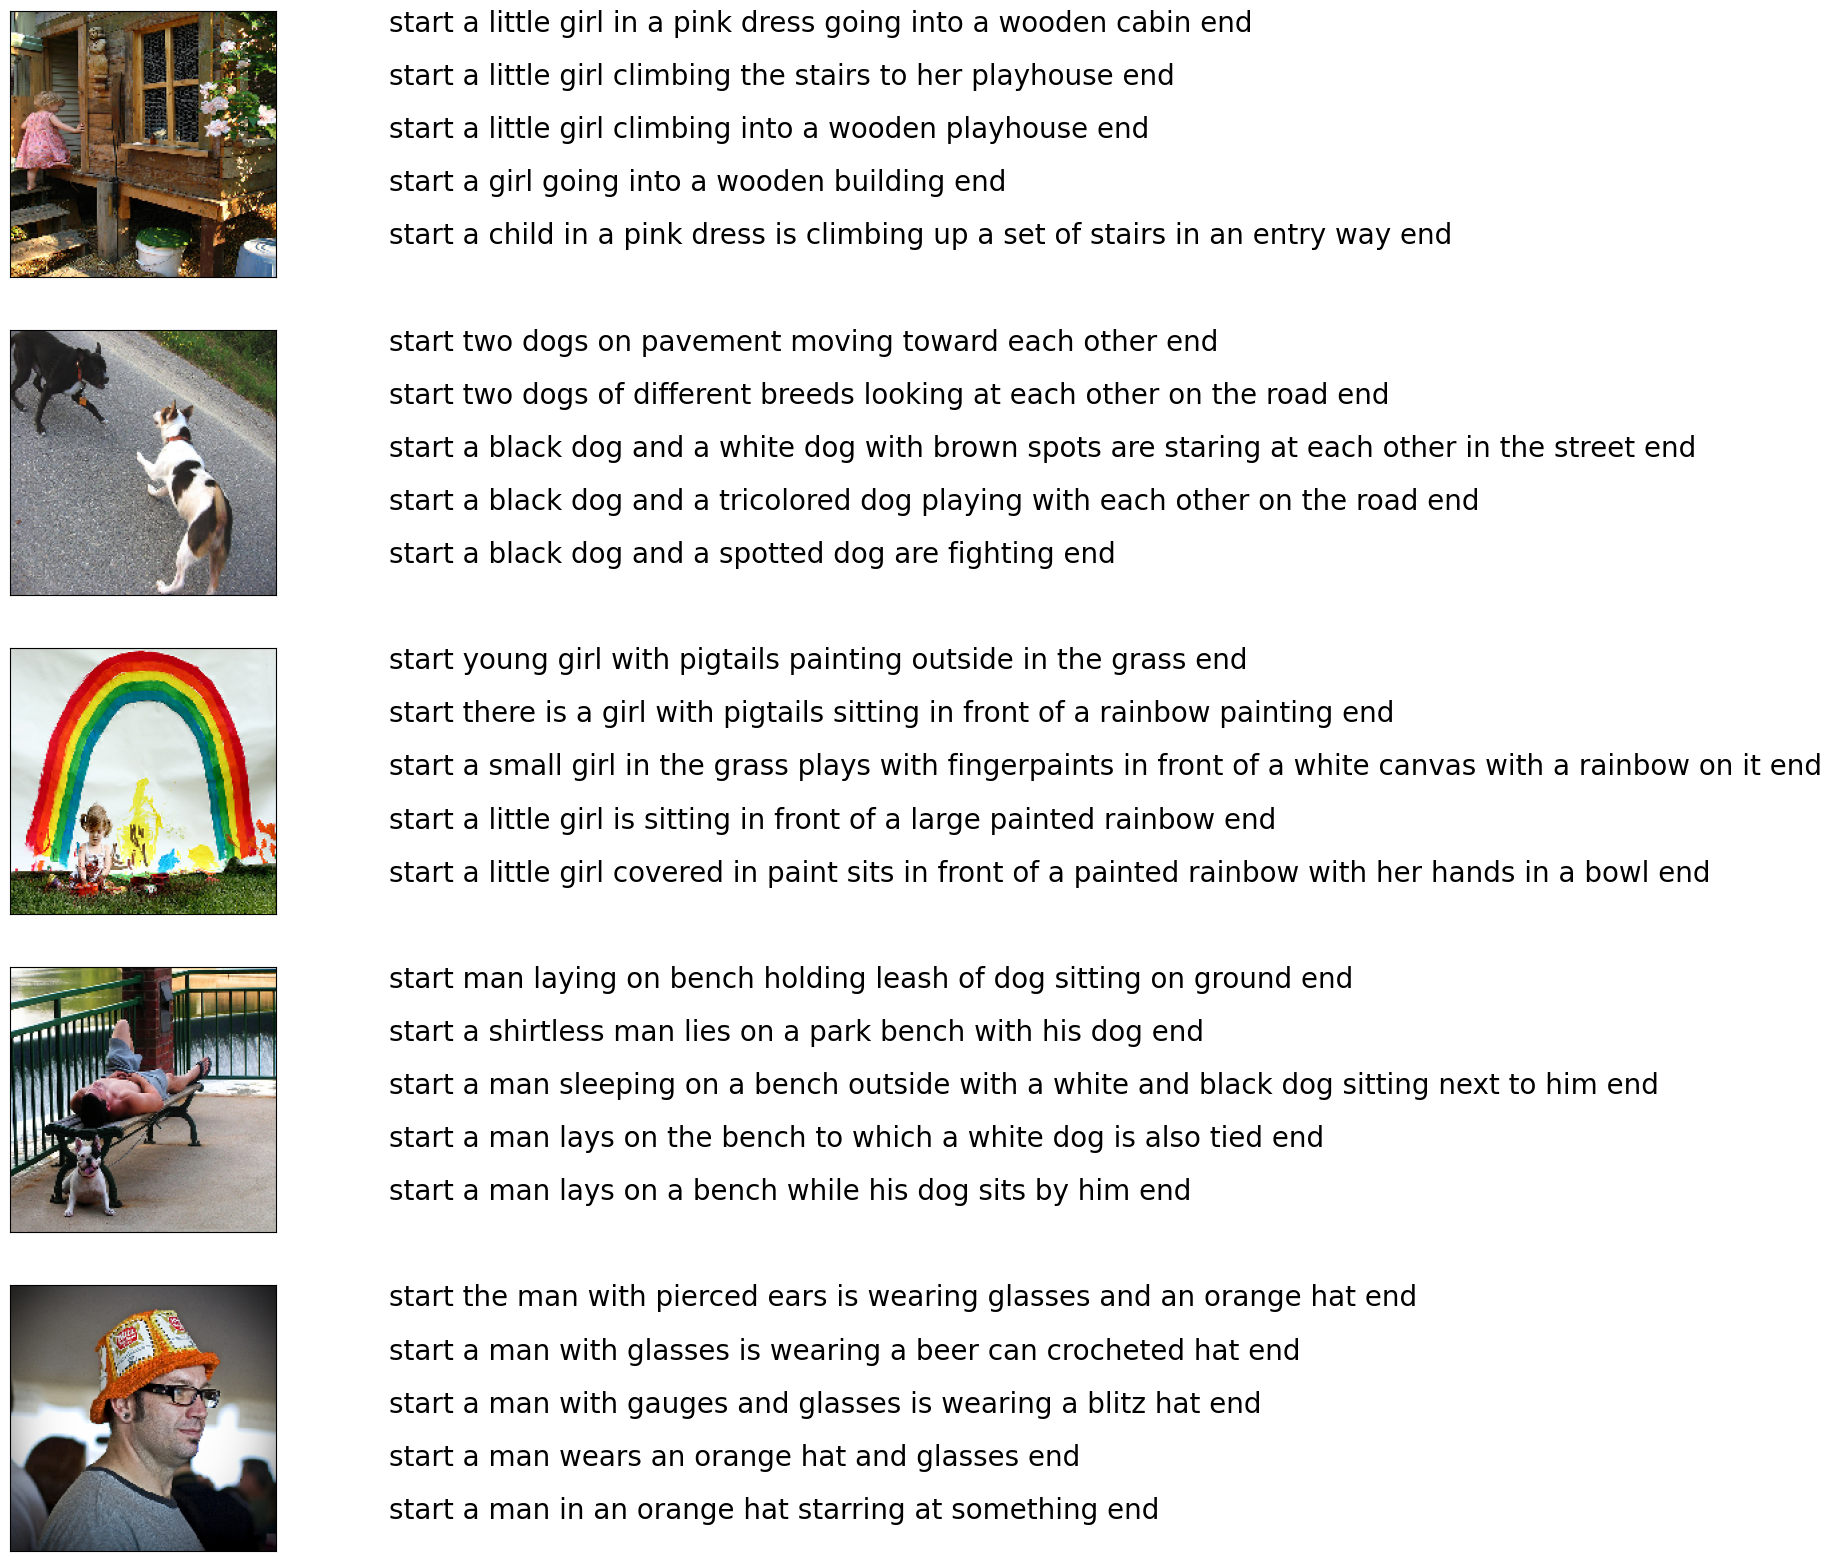

In [6]:
def visualization(data, num_of_images):
    # We use dictionaries to access captions of each image by its ID
    captions_dictionary = {}
    for item in data[0:0+(num_of_images)*5]:
        image_id, caption = item.split('\t')
        if image_id not in captions_dictionary:
            captions_dictionary[image_id] = []
        captions_dictionary[image_id].append(caption)
    else:
        list_captions = [x for x in captions_dictionary.items()]
    
    count = 1
    fig = plt.figure(figsize=(10,20))
    for filename in list(captions_dictionary.keys()):
        captions = captions_dictionary[filename]
        image_load = load_img(images_directory+filename, target_size=(199,199,3))

        ax = fig.add_subplot(num_of_images,2,count,xticks=[],yticks=[])
        ax.imshow(image_load)
        count += 1

        ax = fig.add_subplot(num_of_images,2,count)
        plt.axis('off')
        ax.plot()
        ax.set_xlim(0,1)
        ax.set_ylim(0,len(captions))
        for i, caption in enumerate(captions):
            ax.text(0,i,caption,fontsize=20)
        count += 1
    plt.show()
    
visualization(captions_IDs, 5)

In [7]:
tokenizer = tokenize_captions(cleaned_captions)
vocab_size = len(tokenizer.word_index) + 1

In [8]:
import pickle
with open("/kaggle/input/train-split/train_keys.pkl", "rb") as f:
    train_keys = pickle.load(f)
with open("/kaggle/input/train-split/val_keys.pkl", "rb") as f:
    val_keys = pickle.load(f)
with open("/kaggle/input/train-split/test_keys.pkl", "rb") as f:
    test_keys = pickle.load(f)

In [32]:
all_image_ids = os.listdir(images_directory)
train_image_ids=train_keys
val_image_ids = val_keys
test_image_ids = test_keys

In [93]:
images_directory

'/kaggle/input/flickr8k/Images/'

In [24]:
# 1) build map: "3376898612_41c91de476.jpg" → [ "3376898612_41c91de476.jpg\tstart ... end\n", … ]
cap_map = {}
for item in captions_IDs:
    image_id, _ = item.split('\t', 1)
    cap_map.setdefault(image_id, []).append(item)

# 2) now collect captions in the exact order of train_keys
train_captions = []
for full_path in train_keys:
    image_id = os.path.basename(full_path)
    # extend by all 5 captions (or however many you have) for that image
    train_captions.extend(cap_map.get(image_id, []))

# 3) same for val & test
val_captions = []
for full_path in val_keys:
    image_id = os.path.basename(full_path)
    val_captions.extend(cap_map.get(image_id, []))

test_captions = []
for full_path in test_keys:
    image_id = os.path.basename(full_path)
    test_captions.extend(cap_map.get(image_id, []))

In [28]:
def preprocess_image(image_path):
    img = load_img(image_path, target_size=(224, 224))  # ResNet50 input size
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)  # ResNet50 preprocessing
    return img

def extract_image_features(model, image_path):
    img = preprocess_image(image_path)
    features = model.predict(img, verbose=0)
    return features

# Loading the pre-trained ResNet50 model
resnet50_model = ResNet50(weights='imagenet', input_shape=(224, 224, 3))
resnet50_model = Model(inputs=resnet50_model.inputs, outputs=resnet50_model.layers[-2].output)  # Remove final classification layer

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [59]:
all_image_ids = [
    os.path.basename(p) 
    for p in (train_keys + val_keys + test_keys)
]

In [62]:
train_image_features, val_image_features, test_image_features = {}, {}, {}  # A Dictionary to store image features with their corresponding IDs       

pbar = tqdm_notebook(total=len(all_image_ids), position=0, leave=True, colour='green') 

for caption in all_image_ids:
    image_id = caption.split('\t')[0]
    image_path = os.path.join(images_directory, image_id)
    image_features = extract_image_features(resnet50_model, image_path) # Extracting features
    
    if image_path in train_image_ids:
        train_image_features[image_id] = image_features.flatten()  # Flattening the features
        pbar.update(1)
    
    elif image_path in val_image_ids:
        val_image_features[image_id] = image_features.flatten()  # Flattening the features
        pbar.update(1)
    
    elif image_path in test_image_ids:
        test_image_features[image_id] = image_features.flatten()  # Flattening the features
        pbar.update(1)
    
    else:
        print('Unknown image ID !')
    
pbar.close()

  0%|          | 0/7643 [00:00<?, ?it/s]

In [ ]:
# import pickle

# # Save image features
# with open('train_image_features.pkl', 'wb') as f:
#     pickle.dump(train_image_features, f)

# with open('val_image_features.pkl', 'wb') as f:
#     pickle.dump(val_image_features, f)

# with open('test_image_features.pkl', 'wb') as f:
#     pickle.dump(test_image_features, f)

In [ ]:
# # Loading them back
# import pickle

# with open('/kaggle/input/image-features/test_image_features.pkl', 'rb') as f:
#     train_image_features = pickle.load(f)

# with open('/kaggle/input/image-features/train_image_features.pkl', 'rb') as f:
#     val_image_features = pickle.load(f)

# with open('/kaggle/input/image-features/val_image_features.pkl', 'rb') as f:
#     test_image_features = pickle.load(f)

In [ ]:
# Example image ID
image_id = '1002674143_1b742ab4b8.jpg'

# Check if the image file exists in the dictionary
if image_id in train_image_features:
    print(f"Image {image_id} found in train_image_features.")
    print(f"Image features: {train_image_features[image_id]}")
else:
    print(f"Image {image_id} not found in train_image_features.")


In [ ]:
# def data_generator(captions, image_features, tokenizer, max_caption_length, batch_size):
#     num_samples = len(captions)
#     image_ids = list(image_features.keys())
#     while True:
#         np.random.shuffle(image_ids)  # Shuffle image_ids for each epoch
#         for start_idx in range(0, num_samples, batch_size):
#             end_idx = min(start_idx + batch_size, num_samples)
#             X_images, X_captions, y = [], [], []
#             for caption in captions[start_idx:end_idx]:
#                 image_id, caption_text = caption.split('\t')
#                 caption_text = caption_text.rstrip('\n')
#                 seq = tokenizer.texts_to_sequences([caption_text])[0] # Tokenizing the caption
#                 for i in range(1, len(seq)):
#                     in_seq, out_seq = seq[:i], seq[i] # X_caption, Y
#                     in_seq = pad_sequences([in_seq], maxlen=max_caption_length)[0]
#                     out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
#                     X_images.append(image_features[image_id])
#                     X_captions.append(in_seq)
#                     y.append(out_seq)
            
#             yield [np.array(X_images), np.array(X_captions)], np.array(y)

In [65]:
def data_generator(captions, image_features, tokenizer, max_caption_length, batch_size, vocab_size):
    num_samples = len(captions)
    image_ids = list(image_features.keys())
    while True:
        np.random.shuffle(image_ids)  # Shuffle image_ids for each epoch
        for start_idx in range(0, num_samples, batch_size):
            end_idx = min(start_idx + batch_size, num_samples)
            X_images, X_captions, y = [], [], []
            for caption in captions[start_idx:end_idx]:
                image_id, caption_text = caption.split('\t')
                caption_text = caption_text.rstrip('\n')
                seq = tokenizer.texts_to_sequences([caption_text])[0]  # Tokenizing the caption
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]  # X_caption, Y
                    in_seq = pad_sequences([in_seq], maxlen=max_caption_length)[0]
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
                    X_images.append(image_features[image_id])
                    X_captions.append(in_seq)
                    y.append(out_seq)
            
            # Yielding a tuple: (inputs, targets)
            # Inputs are a tuple of (image features, caption sequences)
            # Targets are the one-hot encoded next words
            yield (
                (np.array(X_images), np.array(X_captions)),
                np.array(y)
            )


In [66]:
def tf_data_generator(captions, image_features, tokenizer, max_caption_length, batch_size, vocab_size):
    def generator():
        for data in data_generator(captions, image_features, tokenizer, max_caption_length, batch_size, vocab_size):
            yield data  # Yield tuple ([X_images, X_captions], y)

    output_signature = (
        (tf.TensorSpec(shape=(None, cnn_output_dim), dtype=tf.float32),
         tf.TensorSpec(shape=(None, max_caption_length), dtype=tf.int32)),
        tf.TensorSpec(shape=(None, vocab_size), dtype=tf.float32)
    )
    
    return tf.data.Dataset.from_generator(generator, output_signature=output_signature)


In [67]:
# Defining the maximum length of captions
max_caption_length = max(len(caption.split()) for caption in cleaned_captions) + 1

# Defining the CNN output dimension (size of feature vector from InceptionV3)
cnn_output_dim = resnet50_model.output_shape[1] # 2048

# Defining batch size
batch_size_train = 270
batch_size_val = 150

# Creating data generators for training and validation
train_data_generator = tf_data_generator(train_captions, train_image_features, tokenizer, max_caption_length, batch_size_train,vocab_size)
val_data_generator = tf_data_generator(val_captions, val_image_features, tokenizer, max_caption_length, batch_size_val,vocab_size)

In [68]:
# Retrieve a single batch from the training generator
(X_images, X_captions), y = next(iter(train_data_generator))

# Check the shapes and types of the outputs
print(f'X_images shape: {X_images.shape}, dtype: {X_images.dtype}')
print(f'X_captions shape: {X_captions.shape}, dtype: {X_captions.dtype}')
print(f'y shape: {y.shape}, dtype: {y.dtype}')

X_images shape: (3079, 2048), dtype: <dtype: 'float32'>
X_captions shape: (3079, 34), dtype: <dtype: 'int32'>
y shape: (3079, 8586), dtype: <dtype: 'float32'>


In [ ]:
image_id = '1002674143_1b742ab4b8.jpg'  # Example image ID
if image_id in image_features:
    X_images.append(image_features[image_id])
else:
    print(f"Image ID {image_id} not found in image_features.")

In [69]:
# Checking shapes
sample_batch = next(train_data_generator)
print("Training sample batch shapes:")
print("X_images:", sample_batch[0][0].shape)
print("X_captions:", sample_batch[0][1].shape)
print("y:", sample_batch[1].shape)
print('=========================')
sample_batch = next(val_data_generator)
print("Validation sample batch shapes:")
print("X_images:", sample_batch[0][0].shape)
print("X_captions:", sample_batch[0][1].shape)
print("y:", sample_batch[1].shape)

TypeError: '_FlatMapDataset' object is not an iterator

In [70]:
def build_model(vocab_size, max_caption_length, cnn_output_dim):
    # Encoder Model
    input_image = Input(shape=(cnn_output_dim,), name='Features_Input')
    fe1 = BatchNormalization()(input_image)
    fe2 = Dense(256, activation='relu')(fe1)  # Adding a Dense layer to the CNN output to match the decoder output size
    fe3 = BatchNormalization()(fe2)
    
    # Decoder Model
    input_caption = Input(shape=(max_caption_length,), name='Sequence_Input')
    se1 = Embedding(vocab_size, 256, mask_zero=True)(input_caption)  # Use mask_zero=True to handle masking in the Embedding layer
    se2 = LSTM(256, use_cudnn=False)(se1)  # Disable cuDNN optimizations if needed
    
    # Output
    decoder1 = add([fe3, se2])
    decoder2 = Dense(256, activation='relu')(decoder1)
    outputs = Dense(vocab_size, activation='softmax', name='Output_Layer')(decoder2)

    # Returning The Model
    model = Model(inputs=[input_image, input_caption], outputs=outputs, name='Image_Captioning')
    return model

In [71]:
caption_model = build_model(vocab_size, max_caption_length, cnn_output_dim)

optimizer = Adam(learning_rate=0.01, clipnorm=1.0)
caption_model.compile(loss='categorical_crossentropy', optimizer=optimizer)

caption_model.summary()

Model: "Image_Captioning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Features_Input            │ (None, 2048)           │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 2048)           │          8,192 │ Features_Input[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Sequence_Input            │ (None, 34)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 256)            │        524,544 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding (Embedding)     │ (None, 34, 256)        │      2,198,016 │ Sequence_Input[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ not_equal (NotEqual)      │ (None, 34)             │              0 │ Sequence_Input[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 256)            │          1,024 │ dense[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm (LSTM)               │ (None, 256)            │        525,312 │ embedding[0][0],       │
│                           │                        │                │ not_equal[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 256)            │              0 │ batch_normalization_1… │
│                           │                        │                │ lstm[0][0]             │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 256)            │         65,792 │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Output_Layer (Dense)      │ (None, 8586)           │      2,206,602 │ dense_1[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 5,529,482 (21.09 MB)

 Trainable params: 5,524,874 (21.08 MB)

 Non-trainable params: 4,608 (18.00 KB)

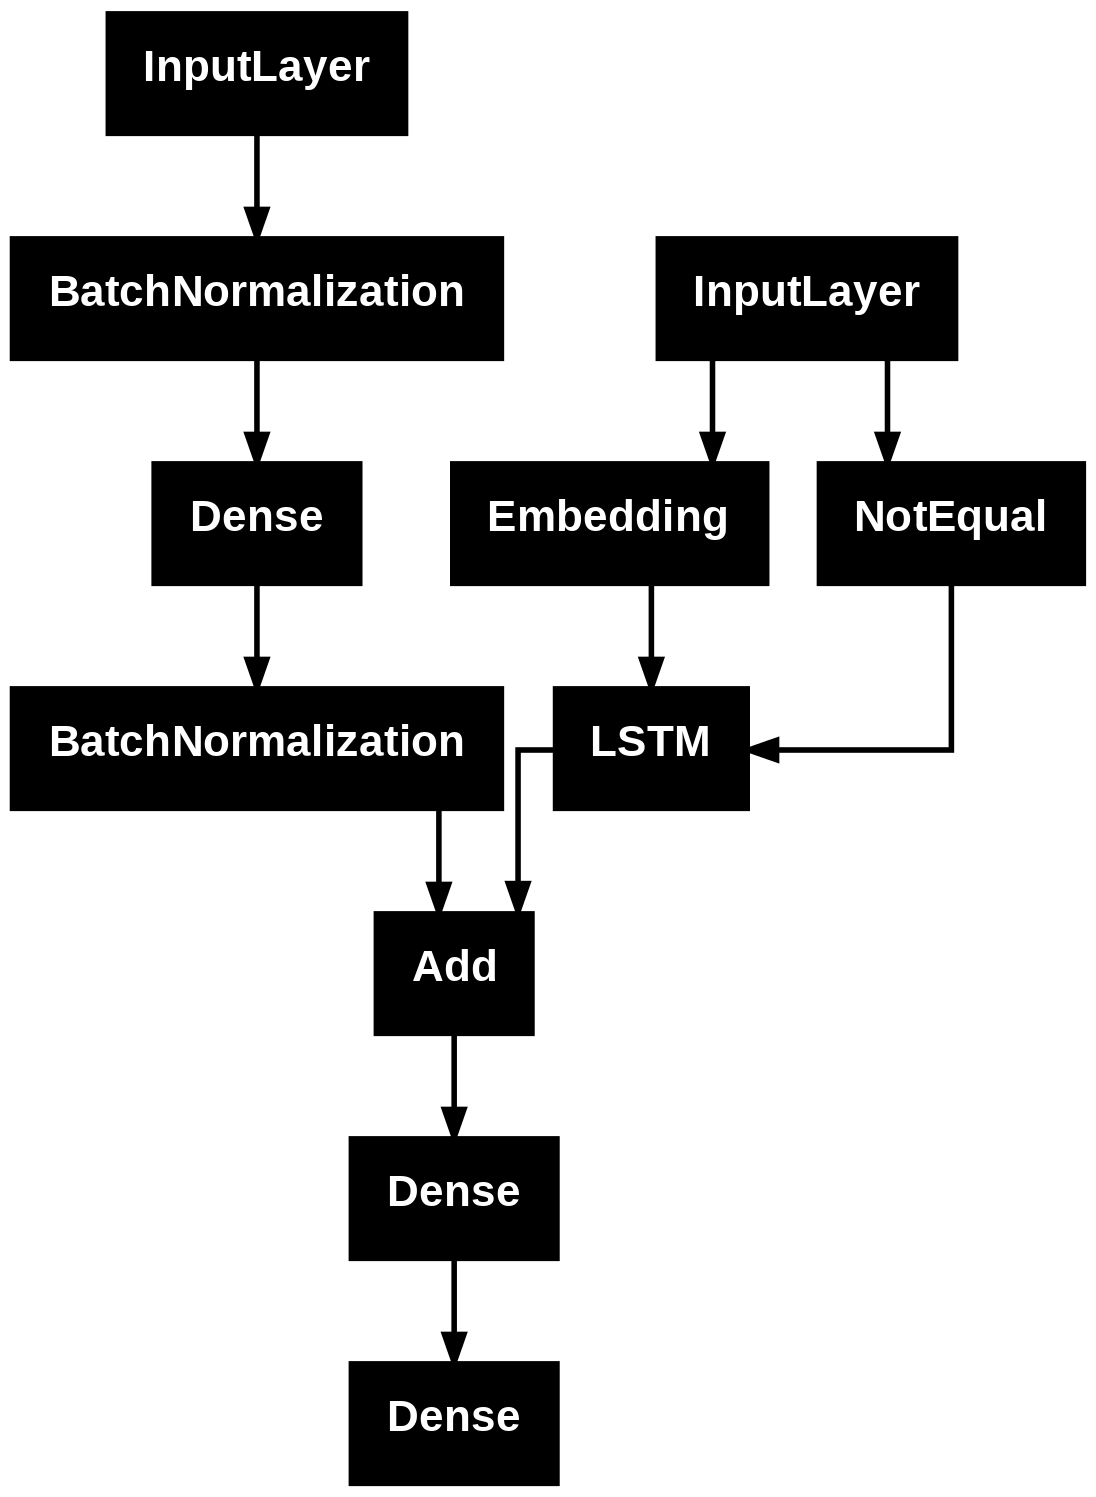

In [72]:
plot_model(caption_model)

In [73]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

def lr_scheduler(epoch, lr):
    new_lr = lr * tf.math.exp(-0.6)
    return float(new_lr)

# Learning Rate Scheduler
lr_schedule = LearningRateScheduler(lr_scheduler)

history = caption_model.fit(train_data_generator, steps_per_epoch=len(train_captions) // batch_size_train,
                        validation_data=val_data_generator, validation_steps=len(val_captions) // batch_size_val,
                        epochs=15, callbacks=[early_stopping, lr_schedule])

Epoch 1/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 294s 3s/step - loss: 5.3088 - val_loss: 3.7745 - learning_rate: 0.0055
Epoch 2/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 51s 462ms/step - loss: 3.3941 - val_loss: 3.4148 - learning_rate: 0.0030
Epoch 3/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 52s 490ms/step - loss: 2.9643 - val_loss: 3.3261 - learning_rate: 0.0017
Epoch 4/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 52s 490ms/step - loss: 2.7271 - val_loss: 3.3032 - learning_rate: 9.0718e-04
Epoch 5/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 47s 442ms/step - loss: 2.5873 - val_loss: 3.3073 - learning_rate: 4.9787e-04
Epoch 6/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 51s 481ms/step - loss: 2.4999 - val_loss: 3.3181 - learning_rate: 2.7324e-04
Epoch 7/15
106/106 ━━━━━━━━━━━━━━━━━━━━ 49s 466ms/step - loss: 2.4450 - val_loss: 3.3221 - learning_rate: 1.4996e-04


In [ ]:
plt.figure(figsize=(15, 7), dpi=200)
sns.set_style('whitegrid')
plt.plot([x+1 for x in range(len(history.history['loss']))], history.history['loss'], color='#E74C3C', marker='o')
plt.plot([x+1 for x in range(len(history.history['loss']))], history.history['val_loss'], color='#641E16', marker='h')
plt.title('Train VS Validation', fontsize=15, fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Loss', fontweight='bold')
plt.legend(['Train Loss', 'Validation Loss'], loc='best')
plt.show()

In [74]:
def greedy_generator(image_features): # A function to generate captions
    # Each caption is started with the word 'start'
    in_text = 'start '
    for _ in range(max_caption_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_caption_length).reshape((1,max_caption_length))
        prediction = caption_model.predict([image_features.reshape(1,cnn_output_dim), sequence], verbose=0)
        idx = np.argmax(prediction)
        word = tokenizer.index_word[idx]
        # Adding the predicted word to the sequence
        in_text += ' ' + word
        # When the model returns the word 'end' (which is the end word), the generating loop must be stopped 
        if word == 'end':
            break
            
    in_text = in_text.replace('start ', '')
    in_text = in_text.replace(' end', '')
    
    return in_text

In [75]:
def beam_search_generator(image_features, K_beams = 3, log = False):
    start = [tokenizer.word_index['start']]
    
    start_word = [[start, 0.0]]
    
    for _ in range(max_caption_length):
        temp = []
        for s in start_word:
            # Sequence of most probable words based on the previous steps
            sequence  = pad_sequences([s[0]], maxlen=max_caption_length).reshape((1,max_caption_length))
            
            preds = caption_model.predict([image_features.reshape(1,cnn_output_dim), sequence], verbose=0)
            
            # Sorting predictions by the probability and taking the last K_beams items.
            word_preds = np.argsort(preds[0])[-K_beams:]
            
            # Getting the top <K_beams>(n) predictions and creating a 
            #                              new list so as to put them via the model again.
            for w in word_preds:
                
                next_cap, prob = s[0][:], s[1]
                next_cap.append(w)
                if log:
                    prob += np.log(preds[0][w]) # assign a probability to each K words
                else:
                    prob += preds[0][w]
                temp.append([next_cap, prob])
                
        start_word = temp
        # Sorting according to the probabilities
        start_word = sorted(start_word, reverse=False, key=lambda l: l[1])

        # Getting the top words
        start_word = start_word[-K_beams:]
    
    start_word = start_word[-1][0]
    captions_ = [tokenizer.index_word[i] for i in start_word]

    final_caption = []
    
    for i in captions_:
        if i != 'end':
            final_caption.append(i)
        else:
            break
    
    final_caption = ' '.join(final_caption[1:])
    return final_caption

In [76]:
# Calculates BLEU score of predictions
def BLEU_score(actual, greedy, beam_search):
    # Calculating the BLEU score by comparing the predicted caption with five actual captions.
    score_greedy_1 = corpus_bleu(actual, greedy, weights=(0.3, 0.3, 0.3, 0))
    score_greedy_2 = corpus_bleu(actual, greedy, weights=(0.25, 0.25, 0.25, 0.25))
    score_BS_1 = corpus_bleu(actual, beam_search, weights=(0.3, 0.3, 0.3, 0))
    score_BS_2 = corpus_bleu(actual, beam_search, weights=(0.25, 0.25, 0.25, 0.25))
    
    return [
        (f'BLEU-2 Greedy: {round(score_BS_2, 5)}'),
        (f'BLEU-1 Greedy: {round(score_BS_1, 5)}'),
        (f'Greedy: {greedy[0]}'),
        (f'BLEU-2 Beam Search: {round(score_greedy_2, 5)}'),
        (f'BLEU-1 Beam Search: {round(score_greedy_1, 5)}'),
        (f'Beam Search:  {beam_search[0]}')
    ]

In [77]:
# A dictionary to access actual captions of each image by its ID
test_actual_captions = {}
for item in test_captions:
    image_id, caption = item.split('\t')
    if image_id not in test_actual_captions:
        test_actual_captions[image_id] = []
    test_actual_captions[image_id].append(caption)

In [78]:
# Generating captions
generated_captions = {}

pbar = tqdm_notebook(total=len(test_image_features), position=0, leave=True, colour='green')
for image_id in test_image_features:
    cap = greedy_generator(test_image_features[image_id])
    generated_captions[image_id] = cap
    pbar.update(1)
    
pbar.close()

  0%|          | 0/383 [00:00<?, ?it/s]

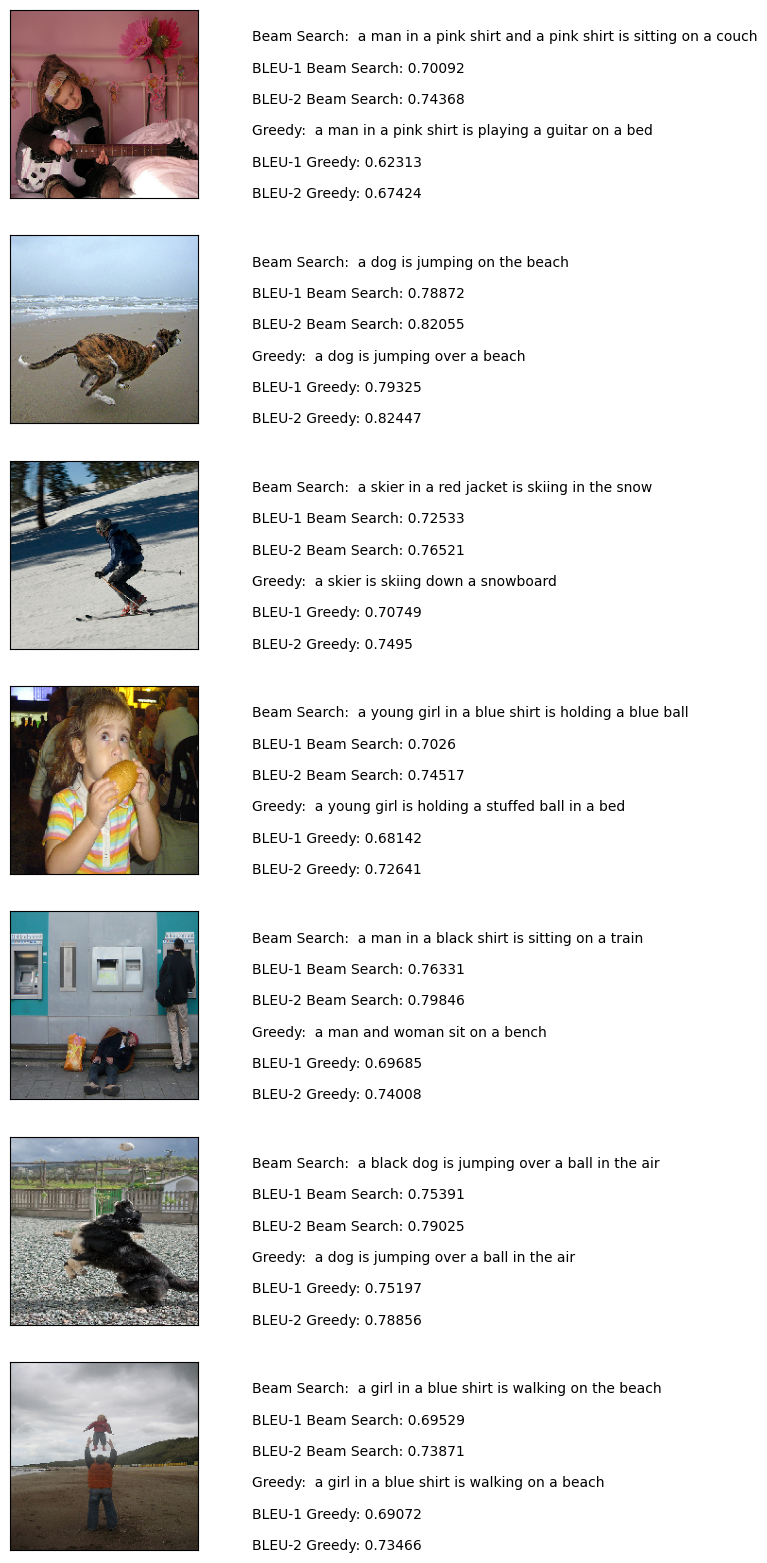

In [82]:
def visualization(data, greedy_caps, beamS_generator, evaluator, num_of_images):
    keys = list(data.keys()) # List of all test images
    images = [np.random.choice(keys) for i in range(num_of_images)] # Randomly selected images
    
    count = 1
    fig = plt.figure(figsize=(6,20))    
    for filename in images:
        actual_cap = data[filename]
        actual_cap = [x.replace("start ", "") for x in actual_cap] # Removing the start token
        actual_cap = [x.replace(" end", "") for x in actual_cap] # Removing the end token
        
        # Generating captions
        greedy_cap = greedy_caps[filename]
        beamS_cap = beamS_generator(test_image_features[filename])
        
        # Getting the bleu score
        caps_with_score = evaluator(actual_cap, [greedy_cap]*(len(actual_cap)), [beamS_cap]*(len(actual_cap)))
    
        image_load = load_img(images_directory+filename, target_size=(199,199,3))
        ax = fig.add_subplot(num_of_images,2,count,xticks=[],yticks=[])
        ax.imshow(image_load)
        count += 1

        ax = fig.add_subplot(num_of_images,2,count)
        plt.axis('off')
        ax.plot()
        ax.set_xlim(0,1)
        ax.set_ylim(0,len(caps_with_score))
        for i, text in enumerate(caps_with_score):
            ax.text(0,i,text,fontsize=10)
        count += 1
    plt.show()

visualization(test_actual_captions, generated_captions, beam_search_generator, BLEU_score, 7)

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

def visualization(data, greedy_caps, beamS_generator, evaluator, num_of_images):
    """
    Shows for num_of_images random samples:
      - the input image
      - its ground-truth captions
      - the greedy-generated caption
      - the beam-search-generated caption
    """
    keys = list(data.keys())
    images = np.random.choice(keys, size=num_of_images, replace=False)

    fig = plt.figure(figsize=(8, 4 * num_of_images))
    count = 1

    for filename in images:
        # Ground-truth captions (strip tokens)
        actual_caps = [
            c.replace("<start> ", "").replace(" <end>", "")
            for c in data[filename]
        ]

        # Greedy and Beam outputs (strip tokens)
        greedy_cap = greedy_caps[filename].replace("<start> ", "").replace(" <end>", "")
        beam_cap   = beamS_generator(test_image_features[filename])\
                        .replace("<start> ", "").replace(" <end>", "")

        # ---- show image ----
        ax_img = fig.add_subplot(num_of_images, 2, count, xticks=[], yticks=[])
        img = load_img(filename, target_size=(199, 199, 3))
        ax_img.imshow(img)
        if count == 1:
            ax_img.set_title("Input Image")
        count += 1

        # ---- show captions ----
        ax_txt = fig.add_subplot(num_of_images, 2, count)
        ax_txt.axis("off")
        if count == 2:
            ax_txt.set_title("Captions")
        display = (
            "Ground truth:\n" + "\n".join(actual_caps)
            + "\n\nGreedy:\n" + greedy_cap
            + "\n\nBeam:\n" + beam_cap
        )
        ax_txt.text(0, 0.5, display, va="center", wrap=True, fontsize=10)
        count += 1

    plt.tight_layout()
    plt.show()

# Example call (evaluator is no longer used but signature remains):
visualization(test_actual_captions, generated_greedy, beam_search_generator, BLEU_score, 5)


NameError: name 'generated_greedy' is not defined

In [97]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

def visualization(data, greedy_caps, beamS_generator, evaluator, num_of_images):
    """
    Shows the first `num_of_images` examples with:
     - the input image
     - its ground-truth captions
     - the greedy-generated caption
     - the beam-search-generated caption
    """
    keys = list(data.keys())[:num_of_images]  # first N images
    fig = plt.figure(figsize=(6, 4 * num_of_images))
    count = 1

    for filename in keys:
        # 1) ground-truth captions, stripped of tokens
        actual_caps = [
            c.replace("<start> ", "").replace(" <end>", "")
            for c in data[filename]
        ]

        # 2) greedy caption
        greedy_cap = greedy_caps[filename]
        greedy_cap = greedy_cap.replace("<start> ", "").replace(" <end>", "")

        # 3) beam-search caption
        beam_cap = beamS_generator(test_image_features[filename])
        beam_cap = beam_cap.replace("<start> ", "").replace(" <end>", "")

        # 4) display image
        ax_img = fig.add_subplot(num_of_images, 2, count, xticks=[], yticks=[])
        ax_img.imshow(load_img(images_directory + filename, target_size=(199, 199, 3)))
        ax_img.axis("off")
        if count == 1:
            ax_img.set_title("Input Image")
        count += 1

        # 5) display all captions
        ax_txt = fig.add_subplot(num_of_images, 2, count)
        ax_txt.axis("off")
        if count == 2:
            ax_txt.set_title("Captions")

        lines = (
            ["Ground truth:"] +
            actual_caps +
            ["", "Greedy:", greedy_cap, "", "Beam:", beam_cap]
        )

        ax_txt.set_xlim(0, 1)
        ax_txt.set_ylim(0, len(lines))
        # draw each line, from top down
        for i, line in enumerate(lines):
            ax_txt.text(0, len(lines) - i - 1, line, fontsize=10)

        count += 1

    plt.tight_layout()
    plt.show()


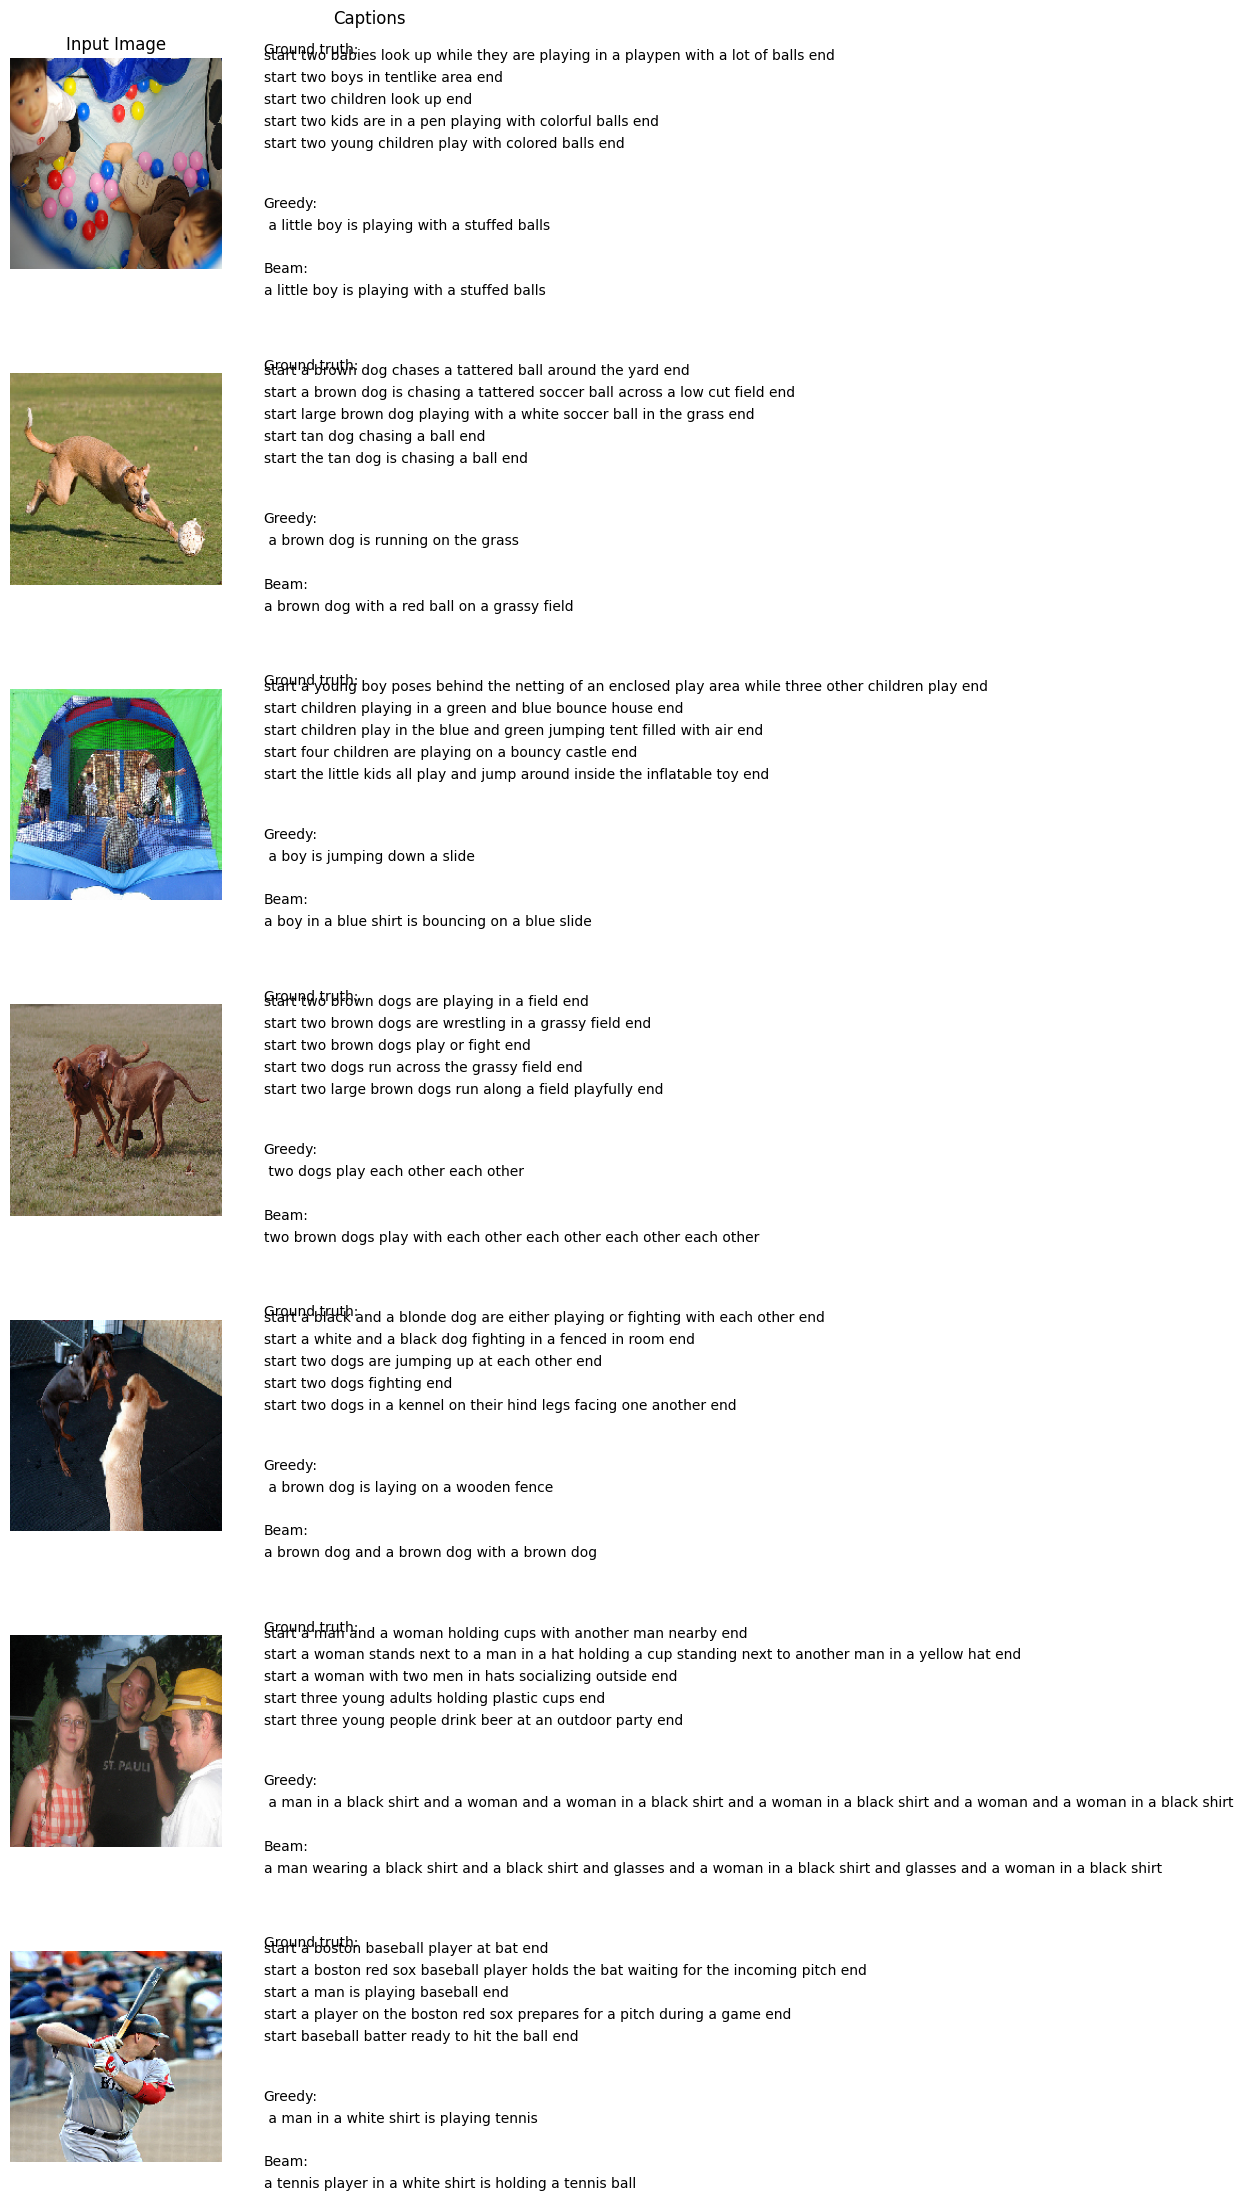

In [98]:
visualization(test_actual_captions, generated_captions, beam_search_generator, BLEU_score, 7)

In [ ]:
def compute_bleu_scores(reference, candidate):
    """
    Compute BLEU-1 and BLEU-2 scores for a given candidate and reference.
    Args:
    - reference: Actual captions (list of lists of tokens)
    - candidate: Generated caption (list of tokens)

    Returns:
    - BLEU-1 and BLEU-2 scores
    """
    # BLEU-1 and BLEU-2 calculation
    bleu_1 = sentence_bleu(reference, candidate, weights=(1, 0, 0, 0), smoothing_function=SmoothingFunction().method1)
    bleu_2 = sentence_bleu(reference, candidate, weights=(0, 1, 0, 0), smoothing_function=SmoothingFunction().method1)
    
    return bleu_1, bleu_2

In [ ]:
from tqdm import tqdm
from nltk.translate.bleu_score import sentence_bleu

def compute_bleu_scores(reference_caps, generated_cap):
    """
    Compute BLEU-1, BLEU-2, BLEU-3, and BLEU-4 scores for a generated caption.
    
    Args:
    - reference_caps: List of actual (reference) captions (tokenized).
    - generated_cap: The generated caption (tokenized).

    Returns:
    - BLEU-1, BLEU-2, BLEU-3, and BLEU-4 scores.
    """
    bleu_1 = sentence_bleu(reference_caps, generated_cap, weights=(1, 0, 0, 0))  # BLEU-1
    bleu_2 = sentence_bleu(reference_caps, generated_cap, weights=(0.5, 0.5, 0, 0))  # BLEU-2
    bleu_3 = sentence_bleu(reference_caps, generated_cap, weights=(0.33, 0.33, 0.33, 0))  # BLEU-3
    bleu_4 = sentence_bleu(reference_caps, generated_cap, weights=(0.25, 0.25, 0.25, 0.25))  # BLEU-4
    
    return bleu_1, bleu_2, bleu_3, bleu_4

def evaluate_bleu(test_data, greedy_caps, beam_search_generator):
    """
    Evaluate the BLEU-1, BLEU-2, BLEU-3, and BLEU-4 scores for both greedy and beam search captions.
    
    Args:
    - test_data: Dictionary containing actual captions for test images.
    - greedy_caps: Dictionary containing generated captions by greedy search.
    - beam_search_generator: Function to generate captions using beam search.

    Returns:
    - average BLEU-1, BLEU-2, BLEU-3, and BLEU-4 scores for both methods.
    """
    greedy_bleu_1_scores = []
    greedy_bleu_2_scores = []
    greedy_bleu_3_scores = []
    greedy_bleu_4_scores = []
    
    beam_bleu_1_scores = []
    beam_bleu_2_scores = []
    beam_bleu_3_scores = []
    beam_bleu_4_scores = []
    
    # Add a progress bar for iterating over the test images
    for image_id in tqdm(test_data.keys(), desc="Evaluating BLEU scores", unit="image"):
        actual_caps = test_data[image_id]
        actual_caps = [cap.replace("start ", "").replace(" end", "").split() for cap in actual_caps]  # Tokenize

        # Get the generated captions
        greedy_cap = greedy_caps[image_id].split()  # Greedy caption tokenized
        beamS_cap = beam_search_generator(test_image_features[image_id]).split()  # Beam Search caption tokenized
        
        # Compute BLEU scores for both greedy and beam search
        bleu_1_greedy, bleu_2_greedy, bleu_3_greedy, bleu_4_greedy = compute_bleu_scores(actual_caps, greedy_cap)
        bleu_1_beamS, bleu_2_beamS, bleu_3_beamS, bleu_4_beamS = compute_bleu_scores(actual_caps, beamS_cap)
        
        greedy_bleu_1_scores.append(bleu_1_greedy)
        greedy_bleu_2_scores.append(bleu_2_greedy)
        greedy_bleu_3_scores.append(bleu_3_greedy)
        greedy_bleu_4_scores.append(bleu_4_greedy)
        
        beam_bleu_1_scores.append(bleu_1_beamS)
        beam_bleu_2_scores.append(bleu_2_beamS)
        beam_bleu_3_scores.append(bleu_3_beamS)
        beam_bleu_4_scores.append(bleu_4_beamS)
    
    # Compute average BLEU-1, BLEU-2, BLEU-3, and BLEU-4 scores for both methods
    avg_bleu_1_greedy = sum(greedy_bleu_1_scores) / len(greedy_bleu_1_scores)
    avg_bleu_2_greedy = sum(greedy_bleu_2_scores) / len(greedy_bleu_2_scores)
    avg_bleu_3_greedy = sum(greedy_bleu_3_scores) / len(greedy_bleu_3_scores)
    avg_bleu_4_greedy = sum(greedy_bleu_4_scores) / len(greedy_bleu_4_scores)
    
    avg_bleu_1_beamS = sum(beam_bleu_1_scores) / len(beam_bleu_1_scores)
    avg_bleu_2_beamS = sum(beam_bleu_2_scores) / len(beam_bleu_2_scores)
    avg_bleu_3_beamS = sum(beam_bleu_3_scores) / len(beam_bleu_3_scores)
    avg_bleu_4_beamS = sum(beam_bleu_4_scores) / len(beam_bleu_4_scores)
    
    # Print average BLEU scores
    print(f"Average BLEU-1 for Greedy Search: {avg_bleu_1_greedy:.4f}")
    print(f"Average BLEU-2 for Greedy Search: {avg_bleu_2_greedy:.4f}")
    print(f"Average BLEU-3 for Greedy Search: {avg_bleu_3_greedy:.4f}")
    print(f"Average BLEU-4 for Greedy Search: {avg_bleu_4_greedy:.4f}")
    
    print(f"Average BLEU-1 for Beam Search: {avg_bleu_1_beamS:.4f}")
    print(f"Average BLEU-2 for Beam Search: {avg_bleu_2_beamS:.4f}")
    print(f"Average BLEU-3 for Beam Search: {avg_bleu_3_beamS:.4f}")
    print(f"Average BLEU-4 for Beam Search: {avg_bleu_4_beamS:.4f}")


In [ ]:
# Example usage
evaluate_bleu(test_actual_captions, generated_captions, beam_search_generator)